In [589]:
import sqlite3
import json

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

conn = sqlite3.connect('../../krisha.kz/db.sqlite')
query = """
SELECT * FROM flats
JOIN prices ON flats.id = prices.flat_id
"""

df = pd.read_sql_query(query, conn)
conn.close()

df['specs'] = df['specs'].apply(json.loads)

# 2. Flatten the 'specs' column into a new DataFrame
specs_expanded = pd.json_normalize(df['specs'])

# 3. Join the new columns back to your original DataFrame
df = pd.concat([df.drop('specs', axis=1), specs_expanded], axis=1)
df.drop(columns=['id', 'photo', 'flat_id', 'star', 'focus', 'date'], inplace=True)
df = df.rename(columns={'type': 'internet', 'balcony_g': 'balcony_glazing'})
df['year'] = df['year'].astype(int)

df.columns.tolist()

df.describe(include='all')

# booleans: priv_dorm, furniture, has_change, balcony_glazing

,url,room,square,city,price,building,complex,year,floor,parking,...,toilet,balcony,door,internet,furniture,flooring,security,renovation,balcony_glazing,phone
count,7327,7327.000000,7327,7327,7.327000e+03,6953,5723,7327.000000,7109,4898,...,4614,3848,3250,2300,3701,3241,3291,3083,1938,1576
unique,7327,NaN,2669,1,NaN,4,944,NaN,378,3,...,3,4,3,4,3,7,139,5,2,4
top,https://krisha.kz/a/show/1009900178,NaN,90 м²,Астана,NaN,монолитный,Respublika,NaN,5 из 9,паркинг,...,2 с/у и более,лоджия,металлическая,оптика,полностью,ламинат,"домофон, видеонаблюдение",свежий ремонт,да,есть возможность подключения
freq,1,NaN,160,7327,NaN,3997,121,NaN,247,4443,...,2408,1603,2385,770,2590,2795,840,1595,1908,833
mean,NaN,3.005596,NaN,NaN,5.236750e+07,NaN,NaN,2015.919749,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,0.074600,NaN,NaN,1.801120e+07,NaN,NaN,11.370950,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,3.000000,NaN,NaN,1.050000e+07,NaN,NaN,1959.000000,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,3.000000,NaN,NaN,3.900000e+07,NaN,NaN,2012.000000,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,3.000000,NaN,NaN,4.990000e+07,NaN,NaN,2020.000000,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,3.000000,NaN,NaN,6.450000e+07,NaN,NaN,2024.000000,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [590]:
df.dropna(subset=['floor'], inplace=True)

df['current_floor'] = df['floor'].str.split().str[0]
df['total_floors'] = df['floor'].str.split().str[-1]

df['current_floor'] = pd.to_numeric(df['current_floor'], errors='coerce')
df['total_floors'] = pd.to_numeric(df['total_floors'], errors='coerce')

df['is_last_floor'] = df['current_floor'] == df['total_floors']
df['is_first_floor'] = df['current_floor'] == 1

print(df[['current_floor', 'is_last_floor', 'is_first_floor']].head(10))
df.head(5)

    current_floor  is_last_floor  is_first_floor
0              14           True           False
1               4          False           False
3               8          False           False
4               8          False           False
5               6          False           False
6               4          False           False
7              12          False           False
8              12           True           False
18              8          False           False
19              3          False           False


,url,room,square,city,price,building,complex,year,floor,parking,...,furniture,flooring,security,renovation,balcony_glazing,phone,current_floor,total_floors,is_last_floor,is_first_floor
0,https://krisha.kz/a/show/1009900178,3,88.6 м²,Астана,67800000,монолитный,Evolution,2025,14,паркинг,...,NaN,NaN,NaN,NaN,NaN,NaN,14,14,True,False
1,https://krisha.kz/a/show/1008564238,3,80 м²,Астана,50500000,кирпичный,Qazyna,2023,4 из 9,паркинг,...,NaN,NaN,NaN,NaN,NaN,NaN,4,9,False,False
3,https://krisha.kz/a/show/1007426712,3,84 м²,Астана,56000000,монолитный,Alan,2019,8 из 9,паркинг,...,полностью,ламинат,"домофон, видеонаблюдение",NaN,NaN,NaN,8,9,False,False
4,https://krisha.kz/a/show/1009267374,3,80 м²,Астана,59500000,кирпичный,GreenLine.Ару Кала,2021,8 из 9,паркинг,...,NaN,NaN,NaN,свежий ремонт,NaN,NaN,8,9,False,False
5,https://krisha.kz/a/show/1009495096,3,66.4 м²,Астана,33000000,монолитный,Sani Towers,2021,6 из 22,паркинг,...,NaN,NaN,NaN,NaN,NaN,NaN,6,22,False,False


In [591]:
df.dropna(subset=['square', 'ceiling'], inplace=True)
df['square_total'] = df['square'].str.split().str[0].astype(float)

df.dropna(subset=['ceiling'], inplace=True)
df['ceiling'] = df['ceiling'].str.split().str[0].astype(float)
df['ceiling'].head(10)



# df['square_kitchen'] = df['square'].str.split().str[-2].astype(float)
# df['square_kitchen'] = np.where(df['square_total'] == df['square_kitchen'], 
#                                 np.nan, 
#                                 df['square_kitchen'])
# print(df['square_kitchen'].isnull().sum())
# print(len(df['square_kitchen']))

0     3.00
1     2.70
3     3.00
4     3.00
5     2.70
6     2.70
7     3.00
8     2.70
18    2.75
19    3.10
Name: ceiling, dtype: float64

In [592]:
# Create a mapping dictionary
mapping = {'да': True, 'нет': False}

# Apply to your columns
df['priv_dorm'] = df['priv_dorm'].str.lower().map(mapping).astype('boolean')
df['has_change'] = df['has_change'].str.lower().map(mapping).astype('boolean')
df['balcony_glazing'] = df['balcony_glazing'].str.lower().map(mapping).astype('boolean')

df['balcony_glazing'] = df['balcony_glazing'].fillna(True)
df['priv_dorm'] = df['priv_dorm'].fillna(False)
df['has_change'].fillna(False)

# Check the results - NaNs stay as NaN
print(df[['priv_dorm', 'has_change', 'balcony_glazing']].value_counts(dropna=False))

print(df[['priv_dorm', 'has_change', 'balcony_glazing']])

priv_dorm  has_change  balcony_glazing
False      False       True               5887
           True        True                382
           False       False                27
True       False       True                  1
           True        True                  1
Name: count, dtype: int64
      priv_dorm  has_change  balcony_glazing
0         False       False             True
1         False       False             True
3         False        True             True
4         False       False             True
5         False       False             True
...         ...         ...              ...
7321      False       False             True
7323      False       False             True
7324      False       False             True
7325      False       False             True
7326      False       False             True

[6298 rows x 3 columns]


In [593]:
df['furniture'] = df['furniture'].fillna('не указан')

# 5. Verify the distribution is still similar to the original
print("New Value Counts (After Probabilistic Fill):")
print(df['furniture'].value_counts(normalize=True))
print(f"\nTotal NaNs remaining: {df['furniture'].isnull().sum()}")

New Value Counts (After Probabilistic Fill):
furniture
не указан     0.457764
полностью     0.379168
частично      0.132105
без мебели    0.030962
Name: proportion, dtype: float64

Total NaNs remaining: 0


In [594]:
print(df.nunique())

url                6298
room                  1
square             2424
city                  1
price               771
building              4
complex             930
year                 67
floor               373
parking               3
ceiling              39
priv_dorm             2
has_change            2
toilet                3
balcony               4
door                  3
internet              4
furniture             4
flooring              7
security            137
renovation            5
balcony_glazing       2
phone                 4
current_floor        31
total_floors         39
is_last_floor         2
is_first_floor        2
square_total        857
dtype: int64


In [595]:
print(df.dtypes)

url                    str
room                 int64
square                 str
city                   str
price                int64
building               str
complex                str
year                 int64
floor                  str
parking                str
ceiling            float64
priv_dorm          boolean
has_change         boolean
toilet                 str
balcony                str
door                   str
internet               str
furniture              str
flooring               str
security               str
renovation             str
balcony_glazing    boolean
phone                  str
current_floor        int64
total_floors         int64
is_last_floor         bool
is_first_floor        bool
square_total       float64
dtype: object


In [596]:
print(df['furniture'].value_counts(dropna=False))

furniture
не указан     2883
полностью     2388
частично       832
без мебели     195
Name: count, dtype: int64


In [597]:
print(df.describe())

         room         price         year      ceiling  current_floor  \
count  6298.0  6.298000e+03  6298.000000  6298.000000    6298.000000   
mean      3.0  5.337252e+07  2016.795808     2.881585       7.114322   
std       0.0  1.755098e+07    10.109951     0.470431       4.360696   
min       3.0  1.050000e+07  1961.000000     2.300000       1.000000   
25%       3.0  4.000000e+07  2013.000000     2.700000       4.000000   
50%       3.0  5.050000e+07  2020.000000     3.000000       6.000000   
75%       3.0  6.500000e+07  2024.000000     3.000000       9.000000   
max       3.0  1.000000e+08  2028.000000    28.000000      42.000000   

       total_floors  square_total  
count   6298.000000   6298.000000  
mean      11.868847     87.180352  
std        5.057046     18.720086  
min        1.000000     37.400000  
25%        9.000000     74.000000  
50%       10.000000     86.000000  
75%       14.000000     96.000000  
max       43.000000    215.000000  


In [598]:
# Select the columns you are analyzing
cols_to_check = [
    'price', 'square', 'year', 'current_floor', 'total_floors', 
    'is_last_floor', 'is_first_floor', 
    'priv_dorm', 'has_change', 'balcony_glazing'
]

# Count the NaNs for each
nan_counts = df[cols_to_check].isnull().sum()

# Display as a percentage to see the "damage"
nan_percentages = (df[cols_to_check].isnull().sum() / len(df)) * 100

# Combine them into a nice summary table
missing_data_summary = pd.DataFrame({
    'Total NaNs': nan_counts,
    'Percentage (%)': nan_percentages.round(2)
})

print(missing_data_summary.sort_values(by='Total NaNs', ascending=False))

                 Total NaNs  Percentage (%)
price                     0             0.0
square                    0             0.0
year                      0             0.0
current_floor             0             0.0
total_floors              0             0.0
is_last_floor             0             0.0
is_first_floor            0             0.0
priv_dorm                 0             0.0
has_change                0             0.0
balcony_glazing           0             0.0


Text(0.5, 1.0, 'Correlation Heatmap: Apartment Features')

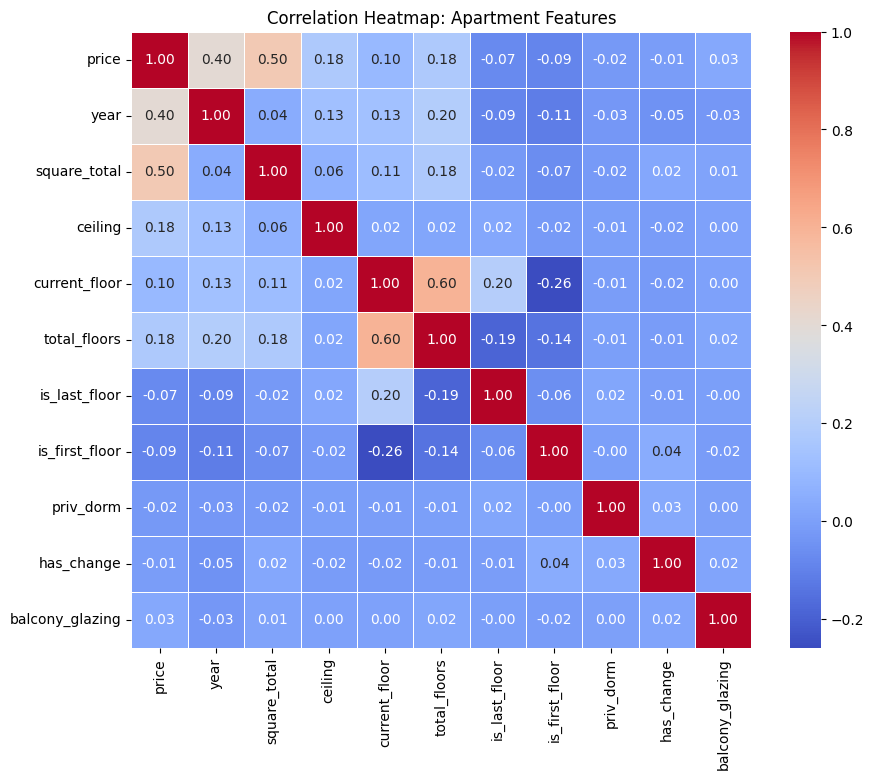

In [599]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Select only the numeric and boolean columns we created
# (Assuming your target column is named 'price')
cols_to_plot = [
    'price', 'year', 'square_total', 'ceiling', 'current_floor', 'total_floors', 
    'is_last_floor', 'is_first_floor', 
    'priv_dorm', 'has_change', 'balcony_glazing',
]

# 2. Calculate the correlation matrix
# Only include columns that actually exist in your df
existing_cols = [c for c in cols_to_plot if c in df.columns]
corr_matrix = df[existing_cols].corr()

# 3. Plot the Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix, 
    annot=True,          # Show the numbers in the boxes
    cmap='coolwarm',     # Red for positive, Blue for negative
    fmt=".2f",           # Limit to 2 decimal places
    linewidths=0.5       # Add thin lines between boxes
)

plt.title('Correlation Heatmap: Apartment Features')

In [600]:
df[[
    'price', 'year', 'square_total', 'ceiling', 'current_floor', 'total_floors', 
    'is_last_floor', 'is_first_floor', 
    'priv_dorm', 'has_change', 'balcony_glazing',
]].isnull().sum()

price              0
year               0
square_total       0
ceiling            0
current_floor      0
total_floors       0
is_last_floor      0
is_first_floor     0
priv_dorm          0
has_change         0
balcony_glazing    0
dtype: int64

In [601]:
df['renovation'] = df['renovation'].fillna('не указан')

# Quick check of the new landscape
print("Renovation distribution after filling:")
print(df['renovation'].value_counts())

Renovation distribution after filling:
renovation
не указан                         3473
свежий ремонт                     1480
не новый, но аккуратный ремонт     879
черновая отделка                   359
требует ремонта                     93
свободная планировка                14
Name: count, dtype: int64


In [602]:
df[[
 'building',
 'complex',
 'parking',
 'toilet',
 'balcony',
 'door',
 'internet',
 'furniture',
 'flooring',
 'security',
 'renovation',
 'balcony_glazing',
 'phone',
 'current_floor',
 'total_floors',
 'is_last_floor',
 'is_first_floor',
 'square_total']].isnull().sum()

building            189
complex             962
parking            1609
toilet             2197
balcony            2759
door               3304
internet           4137
furniture             0
flooring           3287
security           3235
renovation            0
balcony_glazing       0
phone              4819
current_floor         0
total_floors          0
is_last_floor         0
is_first_floor        0
square_total          0
dtype: int64

In [603]:
# df['security'] = df['security'].fillna('не указан')
# security_dummies = df['security'].str.get_dummies(sep=', ')
# if 'не указан' in security_dummies.columns:
#     security_dummies = security_dummies.drop(columns=['не указан'])
# security_dummies = security_dummies.add_prefix('security_')
# df = pd.concat([df, security_dummies.astype(bool)], axis=1)
# print(df.columns)

In [604]:
df['parking'] = df['parking'].fillna('не указан')
parking_mapping = {
    'гараж': 1,
    'рядом охраняемая стоянка': 2,
    'не указан': 3,
    'паркинг': 3,
}

df['parking_score'] = df['parking'].map(parking_mapping)

df.head()

,url,room,square,city,price,building,complex,year,floor,parking,...,security,renovation,balcony_glazing,phone,current_floor,total_floors,is_last_floor,is_first_floor,square_total,parking_score
0,https://krisha.kz/a/show/1009900178,3,88.6 м²,Астана,67800000,монолитный,Evolution,2025,14,паркинг,...,NaN,не указан,True,NaN,14,14,True,False,88.6,3
1,https://krisha.kz/a/show/1008564238,3,80 м²,Астана,50500000,кирпичный,Qazyna,2023,4 из 9,паркинг,...,NaN,не указан,True,NaN,4,9,False,False,80.0,3
3,https://krisha.kz/a/show/1007426712,3,84 м²,Астана,56000000,монолитный,Alan,2019,8 из 9,паркинг,...,"домофон, видеонаблюдение",не указан,True,NaN,8,9,False,False,84.0,3
4,https://krisha.kz/a/show/1009267374,3,80 м²,Астана,59500000,кирпичный,GreenLine.Ару Кала,2021,8 из 9,паркинг,...,NaN,свежий ремонт,True,NaN,8,9,False,False,80.0,3
5,https://krisha.kz/a/show/1009495096,3,66.4 м²,Астана,33000000,монолитный,Sani Towers,2021,6 из 22,паркинг,...,NaN,не указан,True,NaN,6,22,False,False,66.4,3


In [605]:
fur_mapping = {
    'без мебели': 1,
    'частично': 2,
    'не указан': 2,
    'полностью': 3,
}

df['furniture_score'] = df['furniture'].map(fur_mapping)

df.head()

,url,room,square,city,price,building,complex,year,floor,parking,...,renovation,balcony_glazing,phone,current_floor,total_floors,is_last_floor,is_first_floor,square_total,parking_score,furniture_score
0,https://krisha.kz/a/show/1009900178,3,88.6 м²,Астана,67800000,монолитный,Evolution,2025,14,паркинг,...,не указан,True,NaN,14,14,True,False,88.6,3,2
1,https://krisha.kz/a/show/1008564238,3,80 м²,Астана,50500000,кирпичный,Qazyna,2023,4 из 9,паркинг,...,не указан,True,NaN,4,9,False,False,80.0,3,2
3,https://krisha.kz/a/show/1007426712,3,84 м²,Астана,56000000,монолитный,Alan,2019,8 из 9,паркинг,...,не указан,True,NaN,8,9,False,False,84.0,3,3
4,https://krisha.kz/a/show/1009267374,3,80 м²,Астана,59500000,кирпичный,GreenLine.Ару Кала,2021,8 из 9,паркинг,...,свежий ремонт,True,NaN,8,9,False,False,80.0,3,2
5,https://krisha.kz/a/show/1009495096,3,66.4 м²,Астана,33000000,монолитный,Sani Towers,2021,6 из 22,паркинг,...,не указан,True,NaN,6,22,False,False,66.4,3,2


In [606]:
reno_mapping = {
    'требует ремонта': 1,
    'свободная планировка': 2,
    'черновая отделка': 2,
    'не указан': 3,
    'не новый, но аккуратный ремонт': 4,
    'свежий ремонт': 5
}

df['renovation_score'] = df['renovation'].map(reno_mapping)

df.head()

,url,room,square,city,price,building,complex,year,floor,parking,...,balcony_glazing,phone,current_floor,total_floors,is_last_floor,is_first_floor,square_total,parking_score,furniture_score,renovation_score
0,https://krisha.kz/a/show/1009900178,3,88.6 м²,Астана,67800000,монолитный,Evolution,2025,14,паркинг,...,True,NaN,14,14,True,False,88.6,3,2,3
1,https://krisha.kz/a/show/1008564238,3,80 м²,Астана,50500000,кирпичный,Qazyna,2023,4 из 9,паркинг,...,True,NaN,4,9,False,False,80.0,3,2,3
3,https://krisha.kz/a/show/1007426712,3,84 м²,Астана,56000000,монолитный,Alan,2019,8 из 9,паркинг,...,True,NaN,8,9,False,False,84.0,3,3,3
4,https://krisha.kz/a/show/1009267374,3,80 м²,Астана,59500000,кирпичный,GreenLine.Ару Кала,2021,8 из 9,паркинг,...,True,NaN,8,9,False,False,80.0,3,2,5
5,https://krisha.kz/a/show/1009495096,3,66.4 м²,Астана,33000000,монолитный,Sani Towers,2021,6 из 22,паркинг,...,True,NaN,6,22,False,False,66.4,3,2,3


In [607]:
df['building'] = df['building'].fillna('не указан')
building_mapping = {
    'иной': 1,
    'не указан': 1,
    'панельный': 2,
    'кирпичный': 3,
    'монолитный': 4,
}

df['building_score'] = df['building'].map(building_mapping)

df.head()

,url,room,square,city,price,building,complex,year,floor,parking,...,phone,current_floor,total_floors,is_last_floor,is_first_floor,square_total,parking_score,furniture_score,renovation_score,building_score
0,https://krisha.kz/a/show/1009900178,3,88.6 м²,Астана,67800000,монолитный,Evolution,2025,14,паркинг,...,NaN,14,14,True,False,88.6,3,2,3,4
1,https://krisha.kz/a/show/1008564238,3,80 м²,Астана,50500000,кирпичный,Qazyna,2023,4 из 9,паркинг,...,NaN,4,9,False,False,80.0,3,2,3,3
3,https://krisha.kz/a/show/1007426712,3,84 м²,Астана,56000000,монолитный,Alan,2019,8 из 9,паркинг,...,NaN,8,9,False,False,84.0,3,3,3,4
4,https://krisha.kz/a/show/1009267374,3,80 м²,Астана,59500000,кирпичный,GreenLine.Ару Кала,2021,8 из 9,паркинг,...,NaN,8,9,False,False,80.0,3,2,5,3
5,https://krisha.kz/a/show/1009495096,3,66.4 м²,Астана,33000000,монолитный,Sani Towers,2021,6 из 22,паркинг,...,NaN,6,22,False,False,66.4,3,2,3,4


In [608]:
flooring_map = {
    'линолеум': 1,
    'дерево': 1,      # Merged due to similarly low medians
    'ковролан': 2,
    'пробковый': 2,
    'ламинат': 3,
    'плитка': 3,
    'паркет': 4       # The clear winner in value
}

df['flooring_score'] = df['flooring'].map(flooring_map).fillna(3)

In [609]:
toilet_map = {
    'совмещенный': 1,
    'раздельный': 1,
    '2 с/у и более': 3,
}

df['toilet_scoring'] = df['toilet'].map(toilet_map).fillna(2)
df['toilet'].value_counts(dropna=False)

toilet
NaN              2197
2 с/у и более    2146
раздельный       1094
совмещенный       861
Name: count, dtype: int64

In [610]:
balcony_map = {
    'балкон': 1,
    'лоджия': 2,
    'балкон и лоджия': 3,
    'несколько балконов или лоджий': 3  # Merged because 3+ units usually hit a price plateau
}

# Apply mapping and fill NaNs with 0 (representing "No balcony" or "Standard/Unknown")
df['balcony_score'] = df['balcony'].map(balcony_map).fillna(2).astype(int)

In [611]:
door_map = {
    'деревянная': 1,
    'металлическая': 1,  # Merged because medians were nearly identical
    'бронированная': 2
}

# Fill NaNs with 1 (assuming standard/basic door)
df['door_score'] = df['door'].map(door_map).fillna(1).astype(int)

In [612]:
df.columns

Index(['url', 'room', 'square', 'city', 'price', 'building', 'complex', 'year',
       'floor', 'parking', 'ceiling', 'priv_dorm', 'has_change', 'toilet',
       'balcony', 'door', 'internet', 'furniture', 'flooring', 'security',
       'renovation', 'balcony_glazing', 'phone', 'current_floor',
       'total_floors', 'is_last_floor', 'is_first_floor', 'square_total',
       'parking_score', 'furniture_score', 'renovation_score',
       'building_score', 'flooring_score', 'toilet_scoring', 'balcony_score',
       'door_score'],
      dtype='str')

/var/folders/zh/hmpvjk_x02n7scqlxvp07dym0000gn/T/ipykernel_11986/948717358.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[i], x=col, y='price', data=df, palette='viridis', showfliers=False)
/var/folders/zh/hmpvjk_x02n7scqlxvp07dym0000gn/T/ipykernel_11986/948717358.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[i], x=col, y='price', data=df, palette='viridis', showfliers=False)
/var/folders/zh/hmpvjk_x02n7scqlxvp07dym0000gn/T/ipykernel_11986/948717358.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[i],

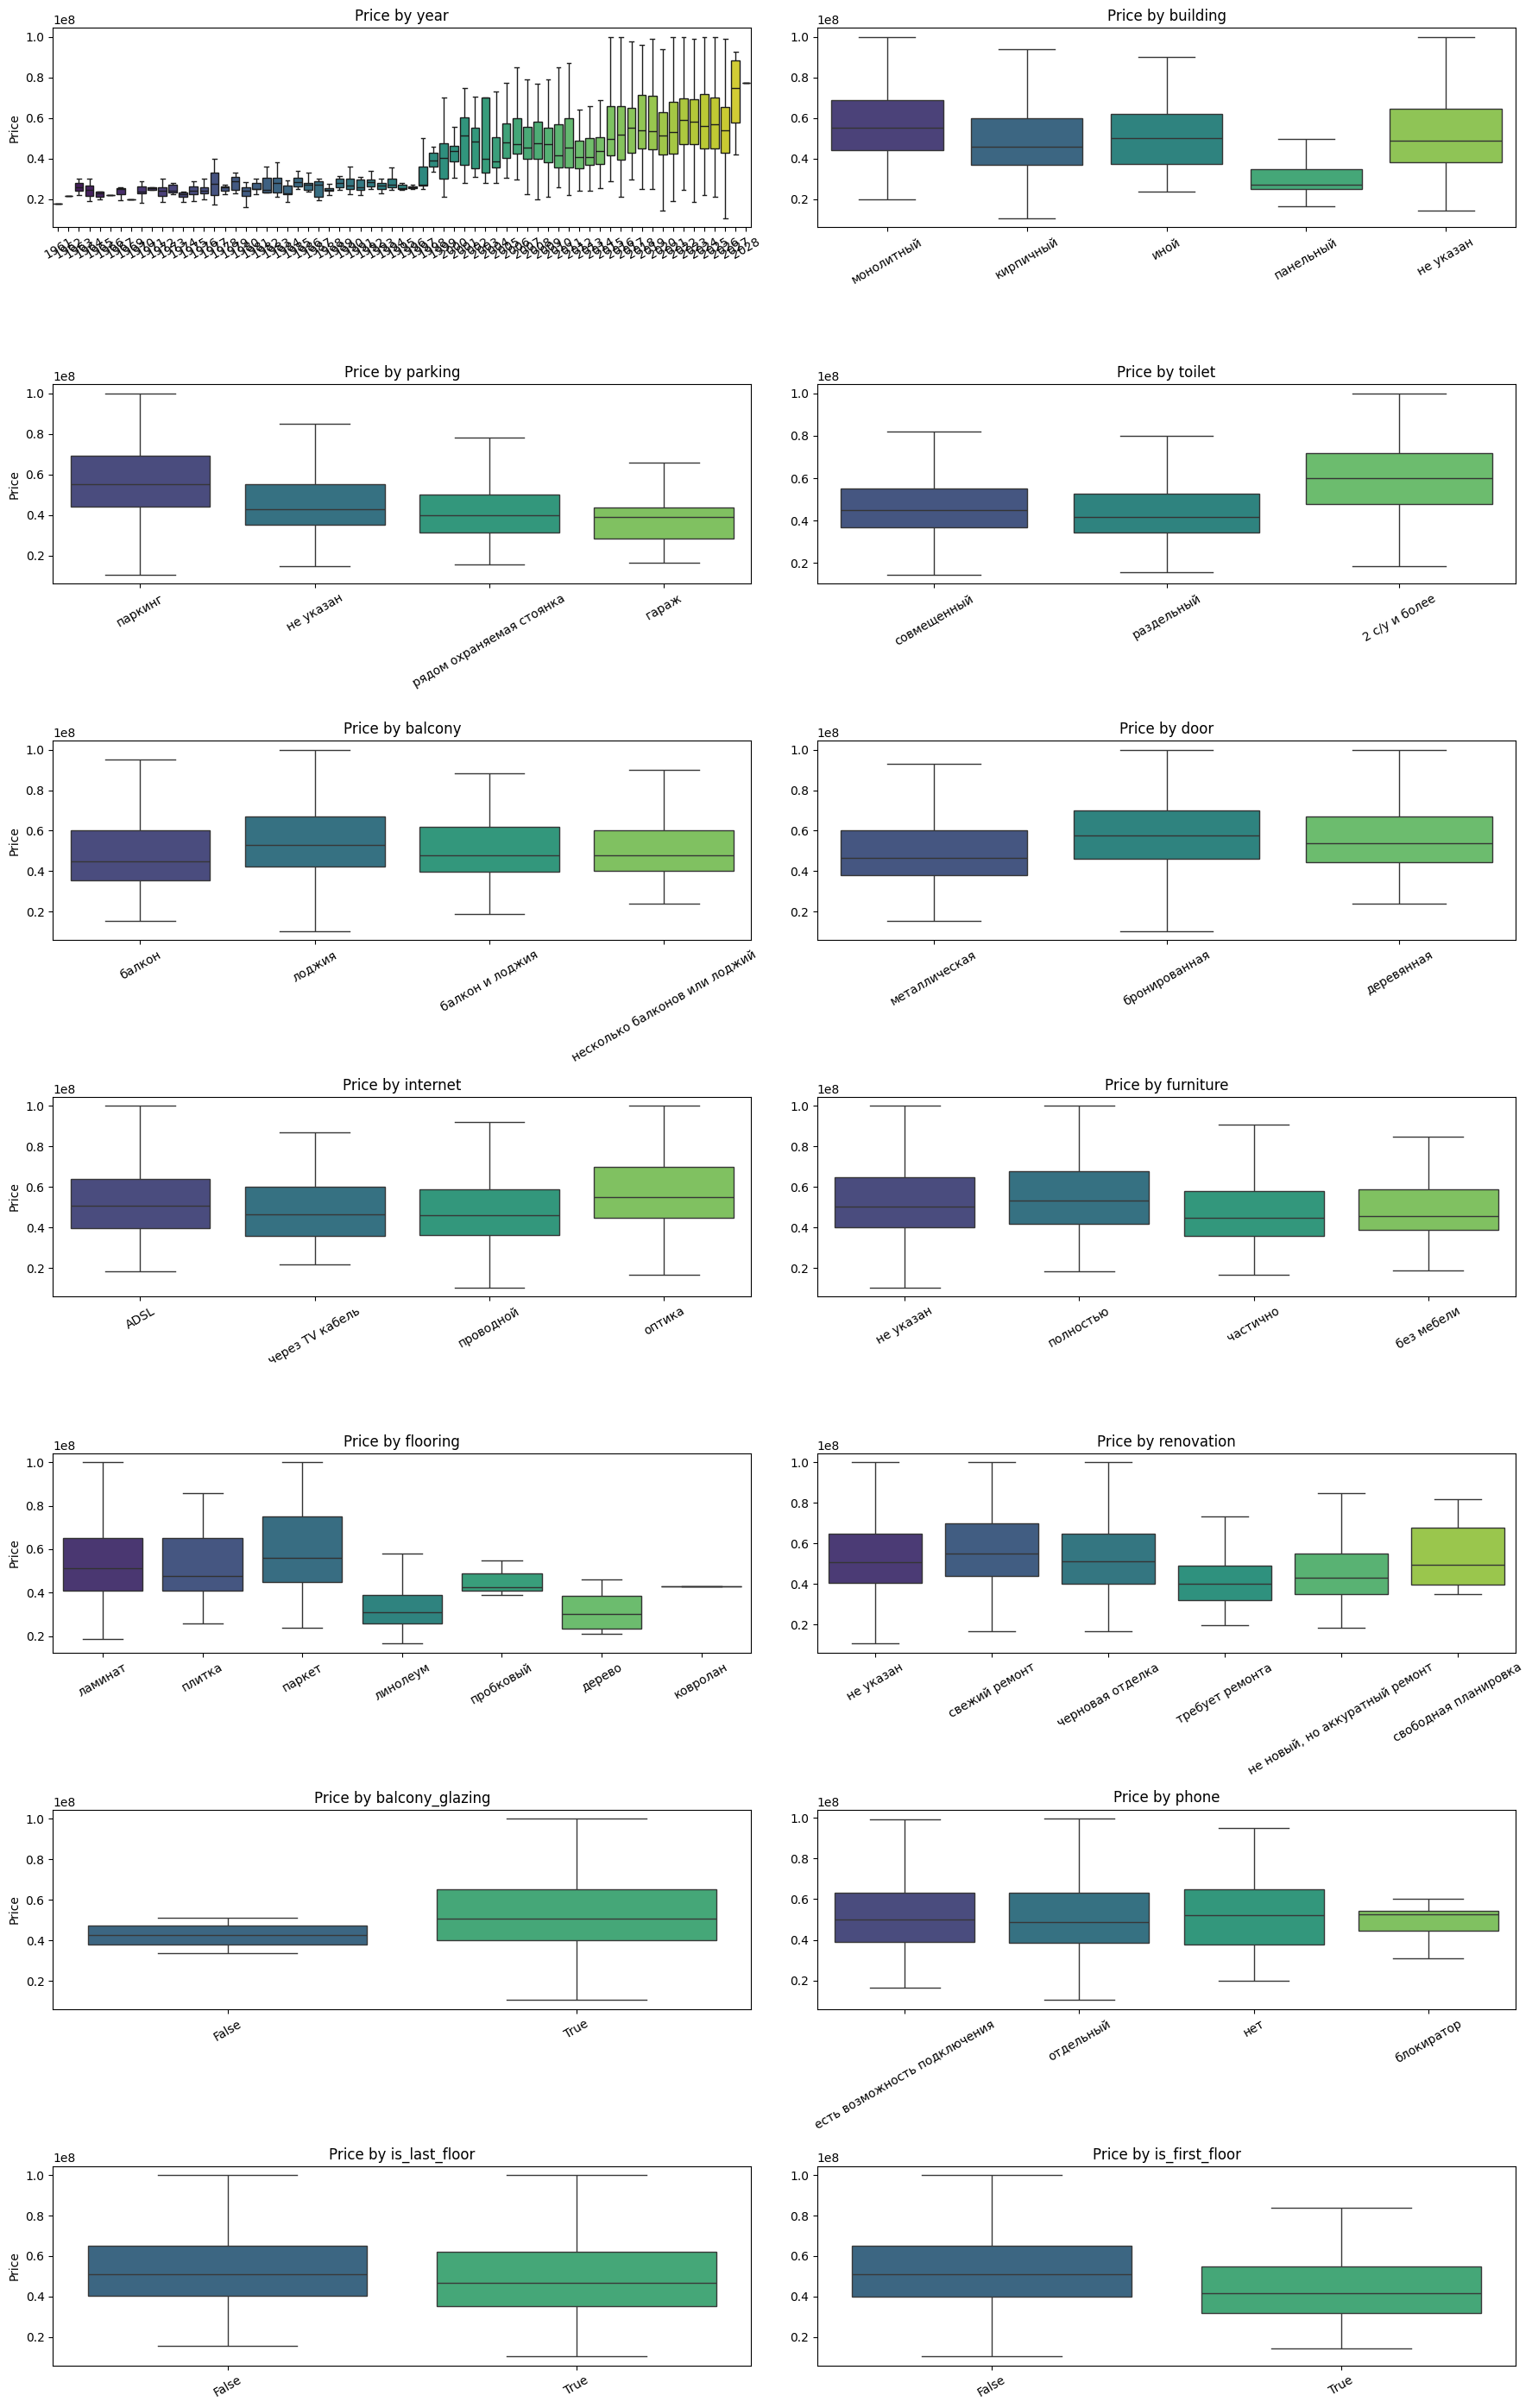

In [613]:
# --- CELL: Categorical Impact on Price (Box Plots) ---
import seaborn as sns
import matplotlib.pyplot as plt
import math

# 1. Define the list of categorical columns you want to analyze
categorical_cols = [
    'year',
    'building',
    'parking',
    'toilet',
    'balcony',
    'door',
    'internet',
    'furniture',
    'flooring',
    'renovation',
    'balcony_glazing',
    'phone',
    'is_last_floor',
    'is_first_floor',
]

n_cols = 2  # Number of charts per row
n_rows = math.ceil(len(categorical_cols) / n_cols)

# 2. Create the Figure
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4))
axes = axes.flatten()  # Flatten to iterate easily

# 3. Loop and Plot
for i, col in enumerate(categorical_cols):
    sns.boxplot(ax=axes[i], x=col, y='price', data=df, palette='viridis', showfliers=False)
    
    axes[i].set_title(f'Price by {col}', fontsize=12)
    axes[i].tick_params(axis='x', rotation=30) # Reduced rotation for compactness
    axes[i].set_xlabel('') # Remove redundant x-labels to save space
    axes[i].set_ylabel('Price' if i % n_cols == 0 else '') # Only show Y label on left charts

# 4. Clean up empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [614]:
df['floor_ratio'] = df['current_floor'] / df['total_floors']

Text(0.5, 1.0, 'Correlation Heatmap: Apartment Features')

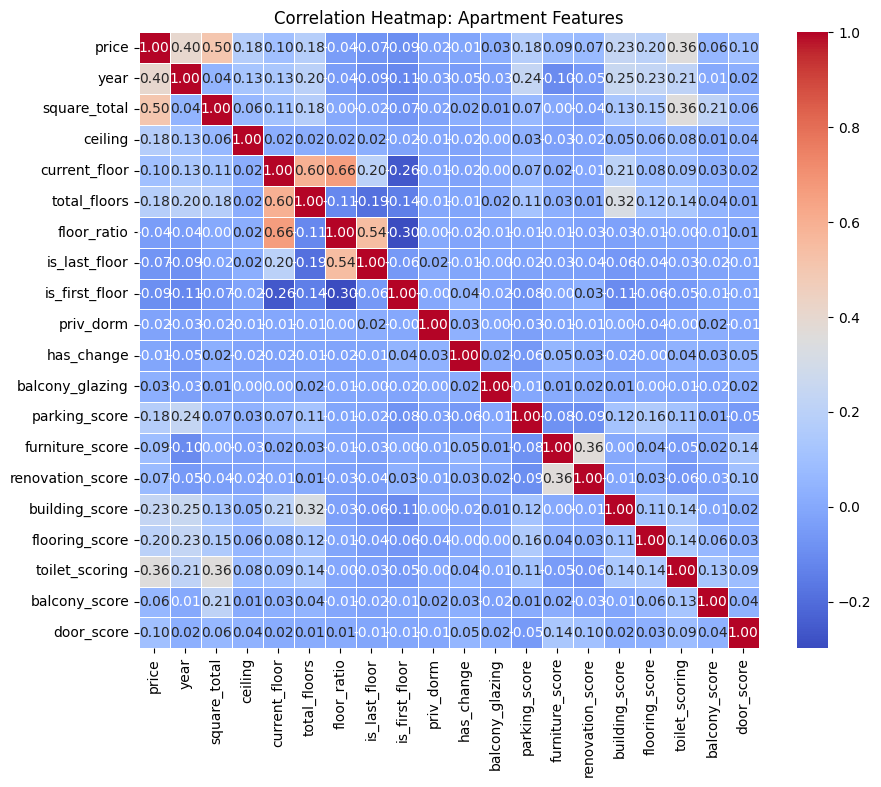

In [615]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Select only the numeric and boolean columns we created
# (Assuming your target column is named 'price')
cols_to_plot = [
    'price', 'year', 'square_total', 'ceiling', 'current_floor', 'total_floors', 'floor_ratio',
    'is_last_floor', 'is_first_floor', 
    'priv_dorm', 'has_change', 'balcony_glazing', 'parking_score', 'furniture_score', 'renovation_score',
       'building_score', 'flooring_score', 'toilet_scoring', 'balcony_score',
       'door_score'
]

"""'url', 'room', 'square', 'city', 'price', 'building', 'complex', 'year',
       'floor', 'parking', 'ceiling', 'priv_dorm', 'has_change', 'toilet',
       'balcony', 'door', 'internet', 'furniture', 'flooring', 'security',
       'renovation', 'balcony_glazing', 'phone', 'current_floor',
       'total_floors', 'is_last_floor', 'is_first_floor', 'square_total',
       ]
"""

# 2. Calculate the correlation matrix
# Only include columns that actually exist in your df
existing_cols = [c for c in cols_to_plot if c in df.columns]
corr_matrix = df[existing_cols].corr()

# 3. Plot the Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix, 
    annot=True,          # Show the numbers in the boxes
    cmap='coolwarm',     # Red for positive, Blue for negative
    fmt=".2f",           # Limit to 2 decimal places
    linewidths=0.5       # Add thin lines between boxes
)

plt.title('Correlation Heatmap: Apartment Features')

In [616]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score

cols_to_train = [
    'price', 'year', 'square_total', 'ceiling', 'total_floors', 'floor_ratio',
    'is_last_floor', 'is_first_floor', 'parking_score', 'furniture_score', 'renovation_score',
    'building_score', 'flooring_score', 'toilet_scoring', 'balcony_score',
    'door_score',
]

# 1. Setup Features and Target
# Ensure 'price' is excluded from X and used as Y
X = df[cols_to_train].drop(columns=['price'])
# Apply log transformation to the target to handle the large price scale
y_log = np.log1p(df['price']) 

# 2. Handle missing values (Standard LinearRegression cannot have NaNs)
X = X.fillna(X.median())

# 3. Train/Test Split
# We use y_log here so the model learns on a smaller, normalized scale
X_train, X_test, y_train_log, y_test_log = train_test_split(X, y_log, test_size=0.2, random_state=42)

# 4. Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 5. Train the Model
model = LinearRegression()
model.fit(X_train_scaled, y_train_log)

# 6. Make Predictions (these will be in log scale)
y_pred_log = model.predict(X_test_scaled)

# 7. Convert predictions back to actual KZT safely
# Clip log values to avoid infinity during exponentiation
y_pred_log_clipped = np.clip(y_pred_log, 0, 25) 
y_pred_actual = np.expm1(y_pred_log_clipped)

# Convert actual test values back to KZT for MAE calculation
y_test_actual = np.expm1(y_test_log)

# 8. Evaluate Performance
# R2 is calculated on the log scale (standard practice for logged targets)
print(f"R2 Score: {r2_score(y_test_log, y_pred_log):.4f}")
# MAE is calculated on real KZT so you can understand the error in money
print(f"Mean Absolute Error: {mean_absolute_error(y_test_actual, y_pred_actual):,.0f} KZT")

R2 Score: 0.5645
Mean Absolute Error: 9,754,577 KZT


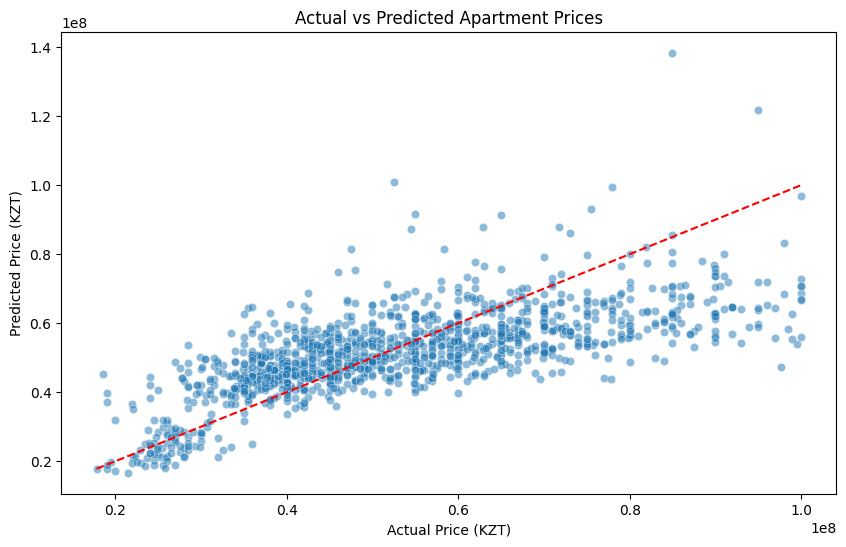

In [617]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test_actual, y=y_pred_actual, alpha=0.5)
plt.plot([y_test_actual.min(), y_test_actual.max()], [y_test_actual.min(), y_test_actual.max()], 'r--')
plt.xlabel('Actual Price (KZT)')
plt.ylabel('Predicted Price (KZT)')
plt.title('Actual vs Predicted Apartment Prices')
plt.show()

In [618]:
from sklearn.ensemble import RandomForestRegressor

# 1. Initialize (n_estimators=100 is a good starting point)
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

# 2. Train (Using the same scaled data from before)
rf_model.fit(X_train_scaled, y_train_log)

# 3. Predict and Evaluate
y_pred_log_rf = rf_model.predict(X_test_scaled)
y_pred_rf = np.expm1(y_pred_log_rf)

print(f"Random Forest R2 Score: {r2_score(y_test_log, y_pred_log_rf):.4f}")
print(f"Random Forest MAE: {mean_absolute_error(y_test_actual, y_pred_rf):,.0f} KZT")

Random Forest R2 Score: 0.7639
Random Forest MAE: 6,775,456 KZT


<Axes: title={'center': 'Feature Importance'}>

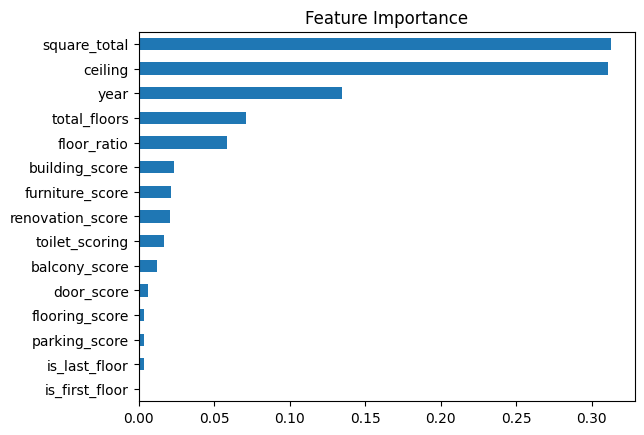

In [619]:
import pandas as pd

importances = pd.Series(rf_model.feature_importances_, index=X.columns)
importances.sort_values().plot(kind='barh', title='Feature Importance')

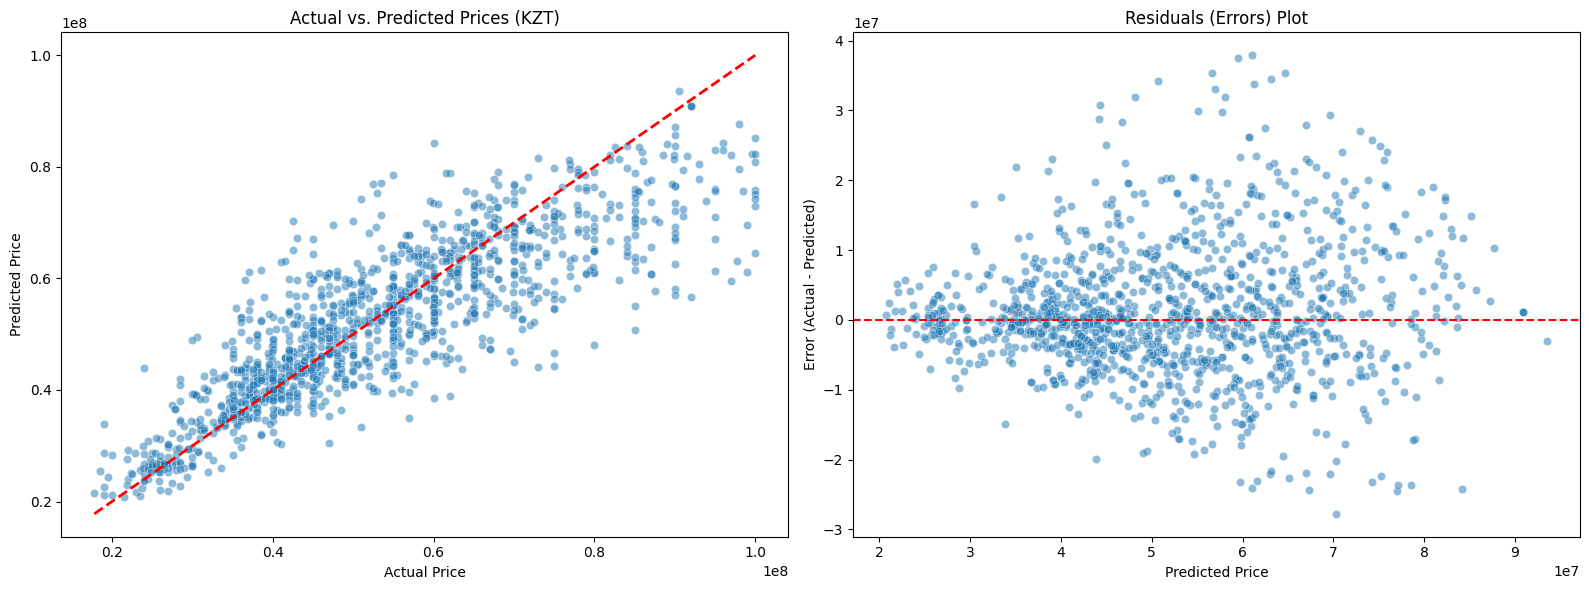

In [620]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Get Predictions (ensure they are back in real KZT)
y_pred_log_rf = rf_model.predict(X_test_scaled)
y_pred_rf = np.expm1(y_pred_log_rf)
y_test_real = np.expm1(y_test_log)

# 2. Create the Figure
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Actual vs Predicted
sns.scatterplot(x=y_test_real, y=y_pred_rf, alpha=0.5, ax=ax1)
ax1.plot([y_test_real.min(), y_test_real.max()], [y_test_real.min(), y_test_real.max()], 'r--', lw=2)
ax1.set_title('Actual vs. Predicted Prices (KZT)')
ax1.set_xlabel('Actual Price')
ax1.set_ylabel('Predicted Price')

# Plot 2: Residuals (The "Misses")
residuals = y_test_real - y_pred_rf
sns.scatterplot(x=y_pred_rf, y=residuals, alpha=0.5, ax=ax2)
ax2.axhline(0, color='r', linestyle='--')
ax2.set_title('Residuals (Errors) Plot')
ax2.set_xlabel('Predicted Price')
ax2.set_ylabel('Error (Actual - Predicted)')

plt.tight_layout()
plt.show()

In [621]:
from sklearn.model_selection import GridSearchCV
import xgboost as xgb

# 1. Define the parameter grid
param_grid = {
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [500, 1000],
    'subsample': [0.8]
}

# 2. Initialize the XGBoost Regressor
xgb_reg = xgb.XGBRegressor(objective='reg:squarederror', random_state=42)

# 3. Setup the Grid Search
grid_search = GridSearchCV(
    estimator=xgb_reg, 
    param_grid=param_grid, 
    cv=3,           # 3-fold cross-validation
    scoring='r2',   # Optimize for R-squared
    verbose=1
)

# 4. Fit to your scaled training data
grid_search.fit(X_train_scaled, y_train_log)

# 5. Get the best model
best_xgb = grid_search.best_estimator_

print(f"Best Parameters: {grid_search.best_params_}")

Fitting 3 folds for each of 18 candidates, totalling 54 fits
Best Parameters: {'learning_rate': 0.01, 'max_depth': 7, 'n_estimators': 1000, 'subsample': 0.8}


In [622]:
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, r2_score
import numpy as np

# 1. Initialize the XGBoost Regressor
# Adjusting hyperparameters to be conservative and prevent overfitting
xgb_model = xgb.XGBRegressor(
    n_estimators=1000,
    learning_rate=0.01,
    max_depth=7,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    objective='reg:squarederror'
)

# 2. Train the model
# We use the log-transformed target (y_train_log) for better stability
xgb_model.fit(X_train_scaled, y_train_log)

# 3. Predict
y_pred_log_xgb = xgb_model.predict(X_test_scaled)

# 4. Inverse transform to actual KZT
y_pred_xgb = np.expm1(y_pred_log_xgb)
y_test_actual = np.expm1(y_test_log)

# 5. Evaluate
print(f"XGBoost R2 Score: {r2_score(y_test_log, y_pred_log_xgb):.4f}")
print(f"XGBoost MAE: {mean_absolute_error(y_test_actual, y_pred_xgb):,.0f} KZT")

XGBoost R2 Score: 0.7685
XGBoost MAE: 6,871,395 KZT
